In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# A learnable control is not yet a reasoning model

Day23 · Chapter13 · DXI-04 bounded CPU sequence microscope. Preserve the earlier G4/G8 negative results. No pretrained weights, GPU, acquisition, API or service.

If a pipeline optimizes a task poorly, is its implementation broken, its reward sparse, its initial policy saturated, or its representation insufficient? A constructive control makes one question easier without pretending the other questions have disappeared. Here a genuinely shared autoregressive TinyDecoder begins unsaturated and receives sampled relative-reward updates—not an exact-reward training shortcut.

Predict → inspect the interface → run all predeclared seeds → perturb stopping and support → interpret every failure. The separately authored English math panel is an evaluation instrument, **not** text understood by this token microscope.

[Chapter13](../../book/chapters/13-group-relative-policy-optimization.md) · [specification](../../experiments/specs/2026-10-04-reasoning-controls.md) · [original negative report](../../experiments/reports/2026-10-04-grpo-diagnostics-distillation.md)

In [2]:
from pathlib import Path
import sys
root=Path.cwd().resolve()
while not (root/"src"/"dongxi_llms").is_dir():
    if root.parent==root: raise RuntimeError("Open within Dongxi_LLMs")
    root=root.parent
sys.path.insert(0,str(root/"src"))
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from dongxi_llms.reasoning_controls import (
    load_fixtures,validate_items,run_controls,SEEDS,UPDATES,oracle_answer,
    expected_success,make_decoder,lookup_control,math_panel_audit,SPLITS
)
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "font.family":"DejaVu Sans","font.size":11,
                     "axes.spines.top":False,"axes.spines.right":False})
colors=["#356a9b","#b97139","#3d8268"]
control,math_items,protocol=load_fixtures()
print(validate_items(control))
print(validate_items(math_items))

{'count': 16, 'by_split': {'train': 4, 'heldout-source': 4, 'heldout-template': 4, 'heldout-family': 4}, 'training_templates': ['predicate-symbolic'], 'training_families': ['sum-positive'], 'suite_sha256': 'cc28a88b27759152befce74325a4ce360b9daea15b2bd998ea2287dc539a7ab2', 'boundary': 'unseen-template rows also have unseen sources; not a pure template ablation'}
{'count': 20, 'by_split': {'train': 8, 'heldout-source': 4, 'heldout-template': 4, 'heldout-family': 4}, 'training_templates': ['arithmetic-symbolic', 'equation-symbolic'], 'training_families': ['arithmetic', 'linear-algebra'], 'suite_sha256': 'f3d46fd8641f4091328790a1ae14479fc6fbb40ad5bf01c0d5245b05196a6881', 'boundary': 'unseen-template rows also have unseen sources; not a pure template ablation'}


## Exercise1 — what exactly is known to be solvable?

The control asks whether a sum of two nonnegative numerals is positive: answer0/1, then EOS. It has a fixed arithmetic oracle. Input is `[BOS, instruction, numeral_a, numeral_b]`; the English question is metadata, not language parsed by the decoder. No answer or reference is injected into its prompt.

Predict what would happen if we only trained a table indexed by the problem key. Could it fit training rows while all unseen keys remain unchanged? Why should that not count as reasoning transfer?

Also predict the split risks: new-template rows have new sources too, while odd-sum is an entirely withheld family. A template effect is not independently isolated here.

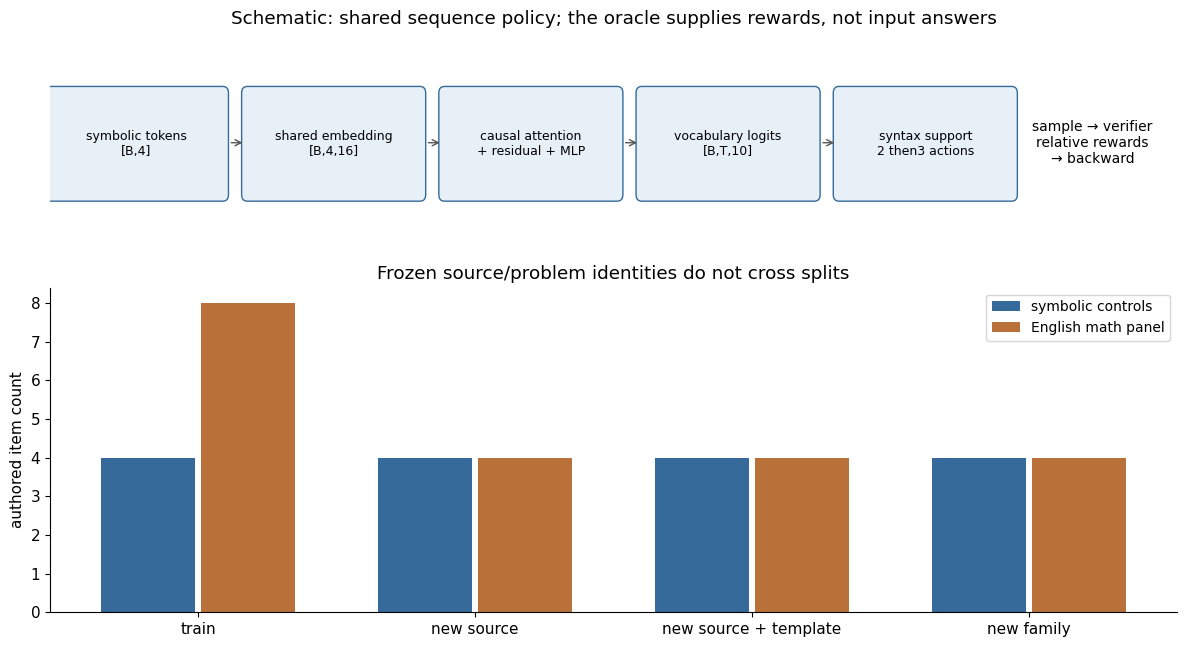

Training families: ['sum-positive']
Withheld English families: ['multi-step']


In [3]:
fig,(map_ax,data_ax)=plt.subplots(2,1,figsize=(12,6.6),
                                    gridspec_kw={"height_ratios":[1,1.5]})
map_ax.set(xlim=(0,6),ylim=(0,1)); map_ax.axis("off")
boxes=[("symbolic tokens\n[B,4]",0),("shared embedding\n[B,4,16]",1.05),
       ("causal attention\n+ residual + MLP",2.1),("vocabulary logits\n[B,T,10]",3.15),
       ("syntax support\n2 then3 actions",4.2)]
for label,x in boxes:
    map_ax.add_patch(FancyBboxPatch((x,.25),.92,.47,boxstyle="round,pad=.03",
                      facecolor="#e8f0f7",edgecolor=colors[0]))
    map_ax.text(x+.46,.485,label,ha="center",va="center",fontsize=9)
    if x<4.2: map_ax.annotate("",xy=(x+1.04,.49),xytext=(x+.95,.49),
                             arrowprops={"arrowstyle":"->","color":"#555555"})
map_ax.text(5.55,.49,"sample → verifier\nrelative rewards\n→ backward",ha="center",va="center",fontsize=10)
map_ax.set_title("Schematic: shared sequence policy; the oracle supplies rewards, not input answers")
x=np.arange(len(SPLITS))
for offset,items,color,label in ((-.18,control,colors[0],"symbolic controls"),
                                  (.18,math_items,colors[1],"English math panel")):
    counts=[sum(i["split"]==s for i in items) for s in SPLITS]
    data_ax.bar(x+offset,counts,width=.34,color=color,label=label)
data_ax.set(xticks=x,xticklabels=["train","new source","new source + template","new family"],
            ylabel="authored item count",title="Frozen source/problem identities do not cross splits")
data_ax.legend(fontsize=10)
plt.tight_layout();plt.show()
print("Training families:",validate_items(control)["training_families"])
print("Withheld English families:",sorted({i["family"] for i in math_items if i["split"]=="heldout-family"}))

**Reference:** the control family is sum-positive; the withheld family is odd-sum. The English panel adds arithmetic, linear equations and a two-step quantity family, but the tiny decoder does not consume those sentences. Source and underlying mathematical problem checks are stronger than an ID-only split check. New-template results still confound template novelty with source novelty.

![Saved schematic and actual fixture counts](../figures/chapter-13/day-23-03_reasoning_tasks_and_positive_controls-01.png)

The top map is architecture, not measured attention. The lower bars count actual fixtures. Rerun the plot after changing a fixture in a separate development experiment.

## Exercise2 — predict genuine sequence learning without a saturated warm-start

Predeclared seeds2301/2302/2303,120 updates each, four prompts×16 responses, two-token cap, no SFT. The first position permits0/1; the next permits0/1/EOS. EOS is genuinely sampled, receives the loss and can fail to appear. Recomputed log probabilities use the same syntax support as collection; this is not raw-vocabulary PPO.

Will increasing average success force every one of the four training items to improve? The positive examples outnumber the single zero-sum case. Predict the failure mode before revealing the run. The exact complete-path probability is a diagnostic only; the decoder trains on sampled rewards and group advantages.

In [4]:
result=run_controls()
runs=result["decoder_runs"]
assert result["seeds"]==list(SEEDS)
assert all(r["updates"]==UPDATES for r in runs)
assert all(r["positive_control_improved"] for r in runs)
for r in runs:
    print("seed",r["seed"],"tokens",r["training_response_tokens"],
          "initialP",np.mean(r["initial_train_complete_path_probabilities"]),
          "finalP",np.mean(r["final_train_complete_path_probabilities"]),
          "task result",r["task_result"])
    assert r["initial_state_sha256"]==r["frozen_state_sha256"]
    assert r["initial_state_sha256"]!=r["final_state_sha256"]
    assert r["history"][0]["first_eos_output_gradient_abs_sum"]>0
    print("first reward/advantages",r["first_and_last_rollout_groups"][0]["rewards"][:16],
          r["first_and_last_rollout_groups"][0]["advantages"][:16])
print("Actual measured CPU seconds:",result["seconds"])

seed 2301 tokens 15360 initialP 0.15679937601089478 finalP 0.9983640909194946 task result all_train_rows_solved
first reward/advantages [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] [-0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, 3.872982978820801, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341, -0.2581988573074341]
seed 2302 tokens 15360 initialP 0.17607935518026352 finalP 0.7499464170050487 task result partial_training_failure_retained
first reward/advantages [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0] [-0.37796449661254883, -0.37796449661254883, 2.645751476287842, -0.37796449661254883, -0.37796449661254883, -0.37796449661254883, -0.37796449661254883, -0.37796449661254883, -0.37796449661254883, -0.37796449661254883, -

**Reference:** all seeds are retained and the final scheduled checkpoint is evaluated—no selection of a best seed or best test checkpoint. Inspect `task_result`: improvement in mean path probability may coexist with a failed known-solvable training item. The paired frozen policy retains initial weights and generates the same seeded outputs as the initial decoder.

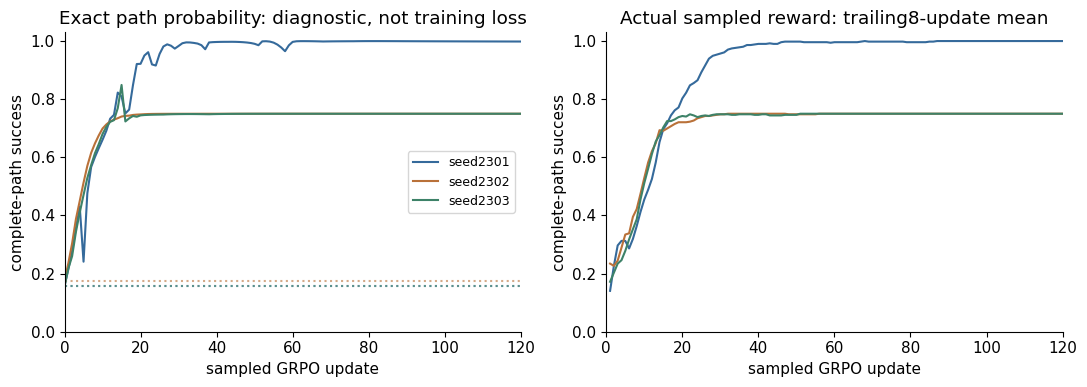

In [5]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
for r,color in zip(runs,colors):
    history=r["history"]
    initial=np.mean(r["initial_train_complete_path_probabilities"])
    y=[initial]+[h["diagnostic_exact_train_success"] for h in history]
    axes[0].plot(range(len(y)),y,color=color,label=f'seed{r["seed"]}')
    axes[0].axhline(initial,color=color,linestyle=":",alpha=.6)
    rewards=np.array([h["sampled_reward"] for h in history])
    smooth=np.array([rewards[max(0,i-7):i+1].mean() for i in range(len(rewards))])
    axes[1].plot(range(1,len(history)+1),smooth,color=color,label=f'seed{r["seed"]}')
for ax in axes:
    ax.set(xlabel="sampled GRPO update",ylabel="complete-path success",ylim=(0,1.03),xlim=(0,UPDATES))
axes[0].set_title("Exact path probability: diagnostic, not training loss")
axes[1].set_title("Actual sampled reward: trailing8-update mean")
axes[0].legend(fontsize=9)
plt.tight_layout();plt.show()

**Reference:** the plotted probability is the product of the correct first-answer probability and the conditional EOS probability after that answer. Dotted lines are frozen initial probabilities. The second panel is a descriptive trailing eight-update mean of recorded sampled rewards, not an exact objective or a selected checkpoint.

![Saved actual seeded learning curves](../figures/chapter-13/day-23-03_reasoning_tasks_and_positive_controls-02.png)

Change group size in a separate `decoder_control` run and declare its new cost. Do not silently reinterpret that intervention as the preregistered experiment.

## Exercise3 — inspect the minority failure and the held-out slices

What could a score of0.5 on four odd-sum prompts mean? A policy returning1 for everything could receive that score without learning oddness. Before looking at the heatmap, predict whether training success alone warrants a family-transfer claim. Inspect actual responses, not only the average.

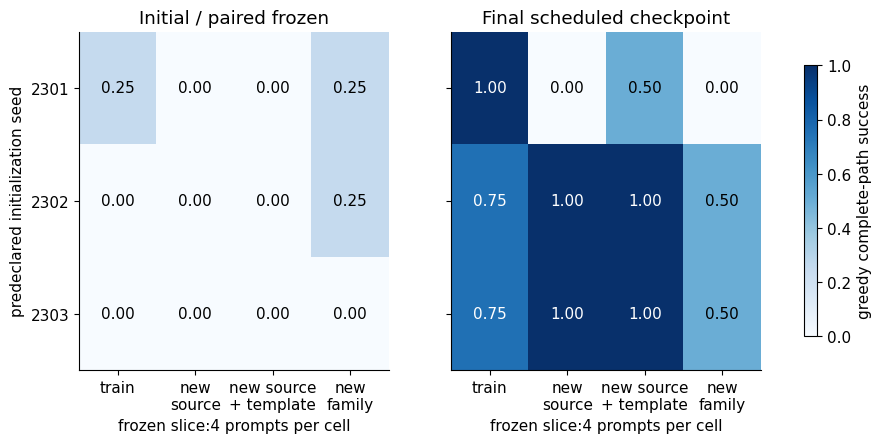

seed 2301 every final greedy failure: [('control-heldout-source-0-2', '0', 'INCORRECT'), ('control-heldout-source-2-0', '0', 'INCORRECT'), ('control-heldout-source-2-2', '0', 'INCORRECT'), ('control-heldout-source-0-3', '0', 'INCORRECT'), ('control-heldout-template-3-0', '0', 'INCORRECT'), ('control-heldout-template-3-3', '0', 'INCORRECT'), ('control-heldout-family-1-3', '1', 'INCORRECT'), ('control-heldout-family-3-1', '1', 'INCORRECT'), ('control-heldout-family-2-3', '0', 'INCORRECT'), ('control-heldout-family-3-2', '0', 'INCORRECT')]
seed 2302 every final greedy failure: [('control-train-0-0', '1', 'INCORRECT'), ('control-heldout-family-1-3', '1', 'INCORRECT'), ('control-heldout-family-3-1', '1', 'INCORRECT')]
seed 2303 every final greedy failure: [('control-train-0-0', '1', 'INCORRECT'), ('control-heldout-family-1-3', '1', 'INCORRECT'), ('control-heldout-family-3-1', '1', 'INCORRECT')]


In [6]:
initial=np.array([[r["initial"]["summaries"][f"{s}/greedy"]["complete_path_success"] for s in SPLITS] for r in runs])
final=np.array([[r["final"]["summaries"][f"{s}/greedy"]["complete_path_success"] for s in SPLITS] for r in runs])
fig,axes=plt.subplots(1,2,figsize=(11,4.4),sharey=True)
for ax,matrix,title in zip(axes,(initial,final),("Initial / paired frozen","Final scheduled checkpoint")):
    im=ax.imshow(matrix,vmin=0,vmax=1,cmap="Blues",aspect="auto")
    ax.set(xticks=range(4),xticklabels=["train","new\nsource","new source\n+ template","new\nfamily"],
           yticks=range(3),yticklabels=[str(r["seed"]) for r in runs],
           xlabel="frozen slice:4 prompts per cell",title=title)
    for row in range(3):
        for col in range(4):
            ax.text(col,row,f"{matrix[row,col]:.2f}",ha="center",va="center",
                    color="white" if matrix[row,col]>.65 else "black")
axes[0].set_ylabel("predeclared initialization seed")
fig.colorbar(im,ax=axes.ravel().tolist(),label="greedy complete-path success",shrink=.8)
plt.show()
for r in runs:
    failures=[(row["item_id"],row["raw_response"],row["status"]) for row in r["final"]["rows"]
              if row["decoding"]=="greedy" and not row["complete_path_success"]]
    print("seed",r["seed"],"every final greedy failure:",failures)

**Reference:** shared parameters can learn a high-reward shortcut. Two predetermined seeds still fail0+0 while fitting the three positive-sum prompts. Do not retune using those final held-out rows or drop the seeds. The unseen-family score does not establish a learned rationale or a causal explanation of generalization; each cell has only four prompts.

![Saved initial/final training and held-out score matrix](../figures/chapter-13/day-23-03_reasoning_tasks_and_positive_controls-03.png)

Trace one failure's symbolic input and generated tokens. The English question is not the actual neural input; avoid attributing a natural-language skill to these numbers.

## Exercise4 — a correct numeral can still be an incomplete trajectory

The cap is part of the task. Predict what happens when cap2 becomes cap1. The common mathematical grader can mark the numeral correct while complete-path reward stays zero because EOS has not been emitted. Separately remove the grammar: raw vocabulary decoding is a different answer-producing system with different support, not a fair proof of training progress under unchanged conditions.

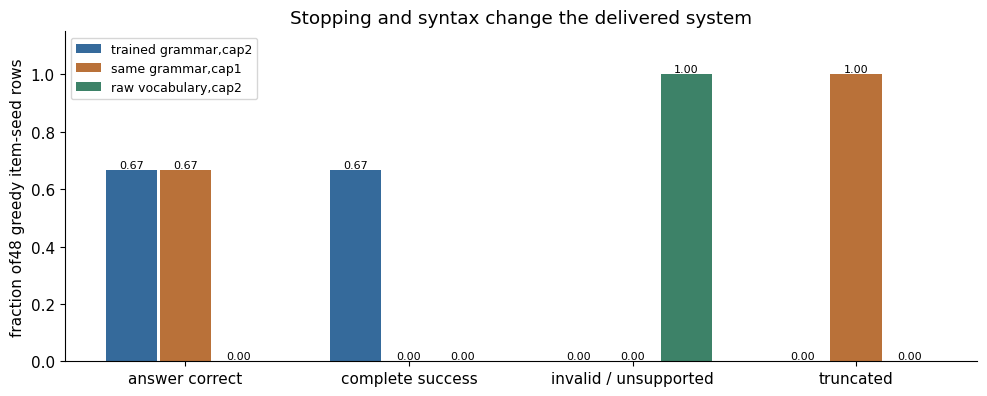

Accounting fractions, all rows retained: [[0.6666666666666666, 0.6666666666666666, 0.0, 0.0], [0.6666666666666666, 0.0, 0.0, 1.0], [0.0, 0.0, 1.0, 0.0]]


In [7]:
def mean_rates(panel):
    rows=[row for r in runs for row in panel(r)["rows"] if row["decoding"]=="greedy"]
    return [np.mean([row["correct"] for row in rows]),
            np.mean([row["complete_path_success"] for row in rows]),
            np.mean([row["status"] not in ("CORRECT","INCORRECT") for row in rows]),
            np.mean([row["truncated"] for row in rows])]
mat=np.array([mean_rates(lambda r:r["final"]),
              mean_rates(lambda r:r["interventions"]["cap1"]),
              mean_rates(lambda r:r["interventions"]["full_vocabulary"])])
fig,ax=plt.subplots(figsize=(10,4.1))
x=np.arange(4)
for offset,vector,color,label in zip((-.24,0,.24),mat,colors,
        ("trained grammar,cap2","same grammar,cap1","raw vocabulary,cap2")):
    bars=ax.bar(x+offset,vector,width=.23,color=color,label=label)
    ax.bar_label(bars,fmt="%.2f",fontsize=8)
ax.set(xticks=x,xticklabels=["answer correct","complete success","invalid / unsupported","truncated"],
       ylabel="fraction of48 greedy item-seed rows",ylim=(0,1.15),
       title="Stopping and syntax change the delivered system")
ax.legend(fontsize=9);plt.tight_layout();plt.show()
assert mat[1,1]==0 and mat[1,3]==1
print("Accounting fractions, all rows retained:",mat.tolist())

**Reference:** answer correctness, output validity and completed-trajectory success are different columns. Cap1 rejects every path, including correct numerals. EOS is included in the sampled response loss, while post-stop padding is excluded. Invalid or truncated rows never disappear from the denominator.

![Saved measured answer/termination accounting](../figures/chapter-13/day-23-03_reasoning_tasks_and_positive_controls-04.png)

## Exercise5 — construct an oracle, then explain why lookup learning is weak evidence

An independently fixed arithmetic oracle can solve every authored item. A table can memorize the four training keys, but new keys use an untouched row. Predict their probability before running the adjacent reference. Why is this exact-expectation fitting arm not a substitute for the sampled decoder arm?

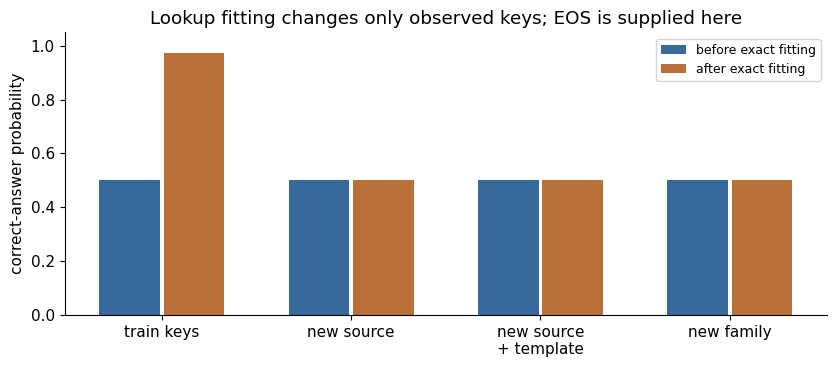

English panel modes: hand-authored oracle/parser probes, NOT language-model generations
Original rational algebra reference examples: [('Solve 2 x + 1 = 7 for x.', '3'), ('Solve 3 x + 2 = 14 for x.', '4'), ('Solve 2 x + 3 = 1 for x.', '-1')]


In [8]:
lookup=result["lookup"]
fig,ax=plt.subplots(figsize=(8.5,3.8))
x=np.arange(4)
for offset,field,color,label in ((-.17,"initial_correct_probability",colors[0],"before exact fitting"),
                                  (.17,"final_correct_probability",colors[1],"after exact fitting")):
    values=[np.mean([row[field] for row in lookup["rows"] if row["split"]==s]) for s in SPLITS]
    ax.bar(x+offset,values,width=.32,color=color,label=label)
ax.set(xticks=x,xticklabels=["train keys","new source","new source\n+ template","new family"],
       ylabel="correct-answer probability",ylim=(0,1.05),
       title="Lookup fitting changes only observed keys; EOS is supplied here")
ax.legend(fontsize=9);plt.tight_layout();plt.show()
assert lookup["unknown_key_probability"]==[.5,.5]
audit=result["math_panel_audit"]
assert all(row["correct"] for row in audit["rows"] if row["variant"]=="oracle")
print("English panel modes:",audit["mode"])
print("Original rational algebra reference examples:",[(i["prompt"],i["reference"]) for i in math_items if i["family"]=="linear-algebra"][:3])

**Reference:** the lookup arm is deliberately exact, per-key and given oracle EOS; the decoder arm instead samples both answer and termination and updates shared neural weights. Their budgets/objectives differ, so these bars are not an algorithm ranking. Oracle/parser probes on English math are authored checks, not model generations.

![Saved lookup counterexample](../figures/chapter-13/day-23-03_reasoning_tasks_and_positive_controls-05.png)

## Exercise6 — which comparison changes weights, and which changes inference?

A base checkpoint and its instruct descendant have different actual weights. Toggling a supported thinking flag on one instruct checkpoint can change its template, output path and token cost without changing those weights. Raw/base, chat/instruct and thinking support must be recorded independently. Is a long correct-looking trace evidence its intermediate steps caused the answer?

In [9]:
for row in protocol["rows"]: print(row)
assert protocol["rows"][0]["checkpoint_id"]!=protocol["rows"][1]["checkpoint_id"]
assert protocol["rows"][1]["checkpoint_id"]==protocol["rows"][2]["checkpoint_id"]
assert all(row["status"]=="unexecuted" for row in protocol["rows"])
print("Predeclared budget interventions:",protocol["budgets"])
print("Boundary:",protocol["boundary"])
print("Parser probes:",[(row["variant"],row["status"],row["correct"],row["truncated"],row["complete_success"])
                       for row in result["math_panel_audit"]["rows"][:4]])

{'checkpoint_role': 'base', 'checkpoint_id': 'separately-pinned-base-weights', 'prompt_mode': 'raw', 'thinking_mode': 'not_a_supported_chat_toggle', 'status': 'unexecuted'}
{'checkpoint_role': 'instruct', 'checkpoint_id': 'separately-pinned-instruct-weights', 'prompt_mode': 'chat', 'thinking_mode': 'disabled_if_supported', 'status': 'unexecuted'}
{'checkpoint_role': 'instruct', 'checkpoint_id': 'separately-pinned-instruct-weights', 'prompt_mode': 'chat', 'thinking_mode': 'enabled_if_supported', 'status': 'unexecuted'}
Predeclared budget interventions: {'final_answer_only': {'max_new_tokens': 32, 'thinking_mode': 'disabled-or-not-supported'}, 'short_work': {'max_new_tokens': 128, 'thinking_mode': 'enabled-only-if-checkpoint-and-template-support-it'}}
Boundary: 32/128 are predeclared interventions, not promises of sufficient reasoning; profile truncation and revisit only on development data. No pretrained row is executed by the CPU control. Toggling thinking is not changing base to instr

**Reference:**32 versus128 output tokens are predeclared interventions for separately approved pretrained runs, not promises that the model reasons. Check actual checkpoint bytes, tokenizer/template identities, support for the flag, stopping, invalid/truncation rates and generated token costs. A final-answer verifier does not validate rationale faithfulness. No pretrained protocol row has been executed here.

The constructive control verifies a bounded mechanism while preserving its own minority and held-out failures. The original G4/G8 negative report also remains unchanged. [Worked solutions11–13](../../book/solutions/13-group-relative-policy-optimization.md) connect this exercise to the capstone evidence boundary.